In [1]:
import pandas as pd
df = pd.read_csv(r"C:\Users\Dell\2015_16_Districtwise.csv\2015_16_Districtwise.csv")

#EDA
print(df.head())
print(df.columns)

   AC_YEAR  STATCD  DISTCD         STATNAME  DISTNAME  DISTRICTS  BLOCKS  \
0  2015-16       1     101  JAMMU & KASHMIR   KUPWARA          1      13   
1  2015-16       1     102  JAMMU & KASHMIR  BARAMULA          1      18   
2  2015-16       1     103  JAMMU & KASHMIR  SRINAGAR          1       8   
3  2015-16       1     104  JAMMU & KASHMIR    BADGAM          1      13   
4  2015-16       1     105  JAMMU & KASHMIR   PULWAMA          1       8   

   VILLAGES  CLUSTERS  TOTPOPULAT  ...  UUNI_ALL  UUNI_SC  UUNI_ST  TOTCLS1G  \
0       391       104    875564.0  ...     21322       26     2594      3489   
1       678       144   1015503.0  ...     17307        0     1571      4127   
2        94        65   1269751.0  ...      5444       31      408       817   
3       523       104    735753.0  ...     12469       18      857      2290   
4       359        64    570060.0  ...      7408       17      855      1688   

   TOTCLS2G  TOTCLS3G  TOTCLS4G  TOTCLS5G  TOTCLS6G  TOTCLS7G 

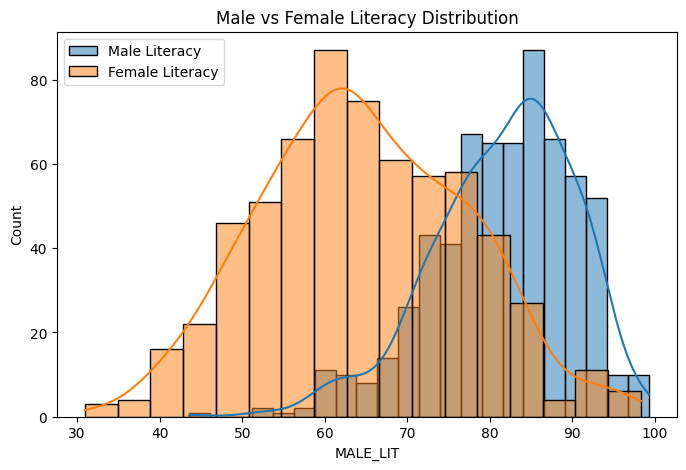

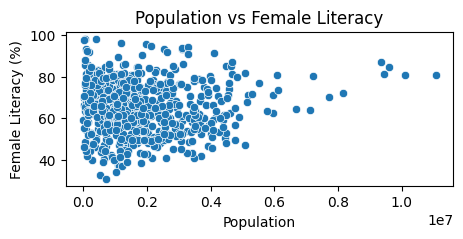

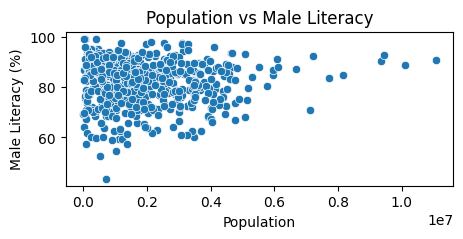

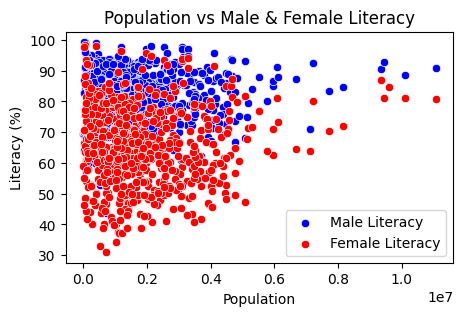

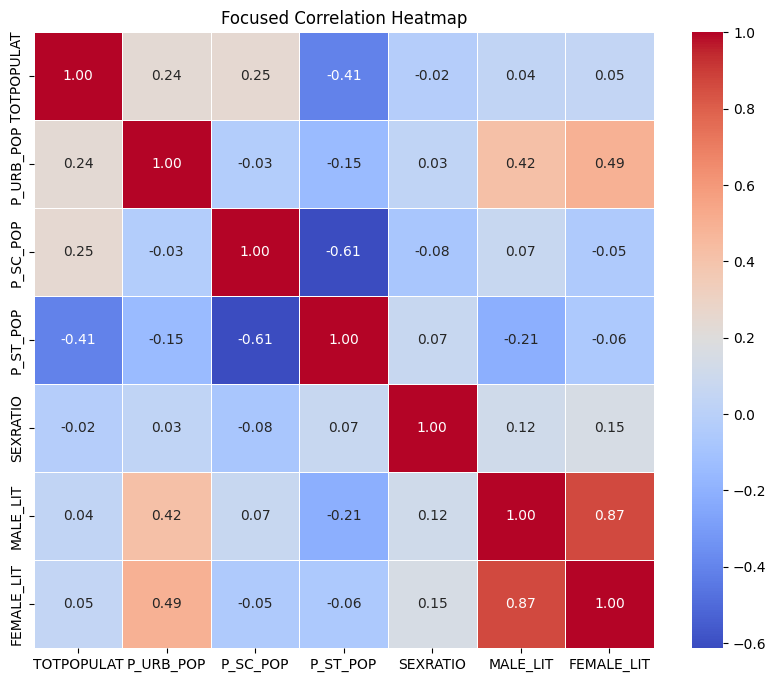

In [5]:
#EDA
[col for col in df.columns if 'lit' in col.lower()]
[col for col in df.columns if 'lit' in col.lower()]
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,5))
sns.histplot(df['MALE_LIT'], kde=True, label='Male Literacy', alpha=0.5)
sns.histplot(df['FEMALE_LIT'], kde=True, label='Female Literacy', alpha=0.5)
plt.legend()
plt.title("Male vs Female Literacy Distribution")
plt.show()

plt.figure(figsize=(5,2))
sns.scatterplot(data=df, x='TOTPOPULAT', y='FEMALE_LIT')
plt.title("Population vs Female Literacy")
plt.xlabel("Population")
plt.ylabel("Female Literacy (%)")
plt.show()

plt.figure(figsize=(5,2))
sns.scatterplot(data=df, x='TOTPOPULAT', y='MALE_LIT')
plt.title("Population vs Male Literacy")
plt.xlabel("Population")
plt.ylabel("Male Literacy (%)")
plt.show()

plt.figure(figsize=(5,3))
sns.scatterplot(data=df, x='TOTPOPULAT', y='MALE_LIT', color='blue', label='Male Literacy')
sns.scatterplot(data=df, x='TOTPOPULAT', y='FEMALE_LIT', color='red', label='Female Literacy')
plt.title("Population vs Male & Female Literacy")
plt.xlabel("Population")
plt.ylabel("Literacy (%)")
plt.legend()
plt.show()

cols_of_interest = [
    'TOTPOPULAT',
    'P_URB_POP',
    'P_SC_POP',
    'P_ST_POP',
    'SEXRATIO',
    'OVERALL_LIT',
    'MALE_LIT',
    'FEMALE_LIT'
]
existing_cols = [col for col in cols_of_interest if col in df.columns]
focused_corr = df[existing_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(focused_corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=.5)
plt.title("Focused Correlation Heatmap")
plt.show()

In [9]:
#Data Preprocessing
from sklearn.preprocessing import LabelEncoder
le_state = LabelEncoder()
le_dist = LabelEncoder()
df['State_Code'] = le_state.fit_transform(df['STATNAME'])
df['District_Code'] = le_dist.fit_transform(df['DISTNAME'])

print("State and District encoders have been fitted.")
print("First 5 rows of encoded data:")
print(df[['STATNAME', 'State_Code', 'DISTNAME', 'District_Code']].head())

State and District encoders have been fitted.
First 5 rows of encoded data:
          STATNAME  State_Code  DISTNAME  District_Code
0  JAMMU & KASHMIR          14   KUPWARA            356
1  JAMMU & KASHMIR          14  BARAMULA             59
2  JAMMU & KASHMIR          14  SRINAGAR            600
3  JAMMU & KASHMIR          14    BADGAM             36
4  JAMMU & KASHMIR          14   PULWAMA            494


In [34]:
#Define Model Training and Evaluation Function
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def train_and_evaluate(target_col):
    print(f"\nTraining model for target: {target_col}")

    X = df_model[['TOTPOPULAT', 'State_Code', 'District_Code']]
    y = df_model[target_col]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Linear Regression
    lr = LinearRegression()
    lr.fit(X_train, y_train)
    y_pred_lr = lr.predict(X_test)

    mae_lr = mean_absolute_error(y_test, y_pred_lr)
    rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
    r2_lr = r2_score(y_test, y_pred_lr)

    print("Linear Regression Performance:")
    print(f"MAE: {mae_lr:.2f}")
    print(f"RMSE: {rmse_lr:.2f}")
    print(f"R²: {r2_lr:.2f}")

    # Random Forest Regressor
    rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    y_pred_rf = rf.predict(X_test)

    mae_rf = mean_absolute_error(y_test, y_pred_rf)
    rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
    r2_rf = r2_score(y_test, y_pred_rf)

    print("Random Forest Performance:")
    print(f"MAE: {mae_rf:.2f}")
    print(f"RMSE: {rmse_rf:.2f}")
    print(f"R²: {r2_rf:.2f}")

    # Plot Actual vs Predicted for Random Forest
    plt.figure(figsize=(8,6))
    plt.scatter(y_test, y_pred_rf, alpha=0.5)
    plt.xlabel("Actual Literacy")
    plt.ylabel("Predicted Literacy")
    plt.title(f"Actual vs Predicted Literacy: {target_col} (Random Forest)")
    plt.show()

    return lr, rf, X_test, y_test, y_pred_rf


In [30]:
#Error Analysis and improvement
error_df = pd.DataFrame({
    'Actual': y_test_o,
    'Predicted': y_pred_rf_o,
    'Error': abs(y_test_o - y_pred_rf_o)
})

top_errors = error_df.sort_values(by='Error', ascending=False).head(10)
print("\nTop 10 districts with largest prediction errors:")
print(top_errors)

# Map these indices back to district names and states
error_indices = top_errors.index.tolist()
print("\nCorresponding Districts and States:")
print(df.loc[error_indices, ['DISTNAME', 'STATNAME', 'OVERALL_LIT']])


NameError: name 'y_test_o' is not defined

In [25]:
# 'top_errors' is the DataFrame with top prediction errors you have
error_indices = top_errors.index.tolist()
# Display district, state, and actual literacy for these indices
print(df.loc[error_indices, ['DISTNAME', 'STATNAME', 'OVERALL_LI']])


          DISTNAME       STATNAME  OVERALL_LI
434      DANTEWADA   CHHATTISGARH       42.67
270            MON       NAGALAND       56.60
373      SAHIBGANJ      JHARKHAND       53.73
301  NORTH TRIPURA        TRIPURA       88.29
312  JAINTIA HILLS      MEGHALAYA       63.26
65          ALMORA    UTTARAKHAND       81.06
278       LONGLENG       NAGALAND       71.10
359        KOLKATA    WEST BENGAL       87.14
667       ANDAMANS  A & N ISLANDS       88.49
39      NAWANSHAHR         PUNJAB       80.33


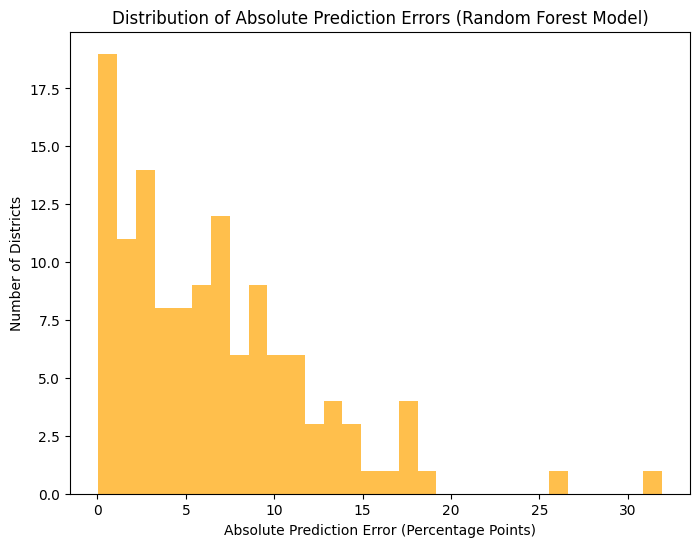

In [26]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
plt.hist(error_df['Error'], bins=30, color='orange', alpha=0.7)
plt.xlabel('Absolute Prediction Error (Percentage Points)')
plt.ylabel('Number of Districts')
plt.title('Distribution of Absolute Prediction Errors (Random Forest Model)')
plt.show()

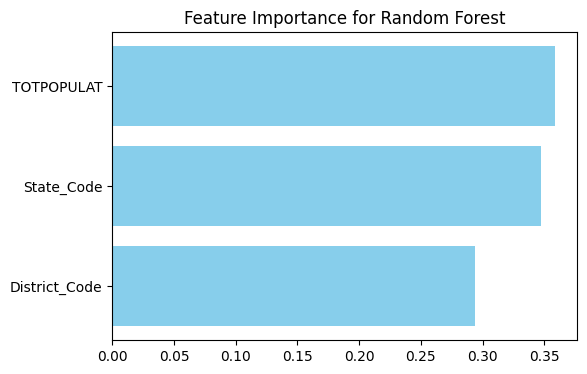

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

features = ['TOTPOPULAT', 'State_Code', 'District_Code']
importances = rf.feature_importances_  # rf is your fitted RandomForestRegressor

feat_imp_df = pd.DataFrame({'Feature': features, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values(by='Importance')

plt.figure(figsize=(6,4))
plt.barh(feat_imp_df['Feature'], feat_imp_df['Importance'], color='skyblue')
plt.title('Feature Importance for Random Forest')
plt.show()


In [28]:
import numpy as np

# Replace TOTPOPULAT with its log in df_model
df_model['log_TOTPOPULAT'] = np.log1p(df_model['TOTPOPULAT'])

# Use log_TOTPOPULAT instead of TOTPOPULAT in feature set:
X = df_model[['log_TOTPOPULAT', 'State_Code', 'District_Code']]
y = df_model['OVERALL_LI']

# Proceed with train-test split and modeling as before
